# SOB4ES - Modelo Random Forest
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo Random Forest.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda aleatoria de hiperparametros.
4. Validacion cruzada: evaluacion de robustez.
5. Explicabilidad (SHAP): analisis de importancia de variables.
6. Produccion: entrenamiento del ensamble final y exportacion.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno


In [12]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

import itertools
from matplotlib.colors import LinearSegmentedColormap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import shap
import matplotlib.pyplot as plt

# ignoramos los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/rf/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon 
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}
# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [13]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [14]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros de `RandomForestRegressor`. La busqueda se ejecuta exclusivamente sobre `X_train`. Como variable objetivo de referencia se usa `earthworm_shannon_z`.

Principales hiperparametros explorados:
- `n_estimators`: numero de arboles en el bosque.
- `max_depth`: profundidad maxima de cada arbol.
- `min_samples_split` / `min_samples_leaf`: criterios de parada para la division de nodos.
- `max_features`: numero de variables consideradas en cada split.
- `bootstrap`: si se usa muestreo con reemplazamiento.


Para reducir el riesgo de sobreajuste con un dataset pequeño (~300 muestras), el grid se restringe: `max_depth` maximo 20, `min_samples_leaf` minimo 2, forzando `bootstrap=True` para mayor variabilidad entre arboles.


Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Buscando hiperparametros para: earthworm_shannon_z
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  R2: 0.4538  |  tiempo: 0.1 min
  Params: {'random_state': 42, 'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 5, 'ccp_alpha': 0.005, 'bootstrap': True}

Buscando hiperparametros para: earthworm_richness_z
Fitting 5 folds for each of 50 candidates, totalling 250 fits
  R2: 0.5243  |  tiempo: 0.1 min
  Params: {'random_state': 42, 'n_estimators': 150, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 5, 'ccp_alpha': 0.005, 'bootstrap': True}

Busqueda de hiperparametros completada en 0.1 minutos.

Calculando consenso de hiperparametros...
  Peso earthworm_shannon_z  : 0.464
  Peso earthworm_richness_z : 0.536

Hiperparametros consenso finales para Random Forest:
  n_estimators: 150
  max_depth: 5
 

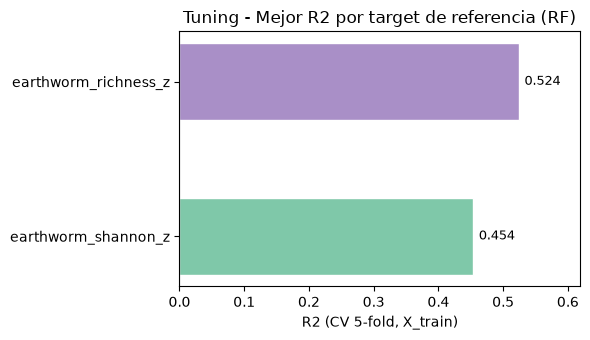

In [15]:
print('Iniciando busqueda de hiperparametros (Tuning)...')
print('Este proceso puede tardar varios minutos.\n')

param_grid = {
	'n_estimators':      [100, 150, 200],
	'max_depth':         [3, 4, 5],
	'min_samples_leaf':  [8, 12, 16],
	'min_samples_split': [15, 20, 25],
	'max_features':      ['sqrt', 0.2, 0.3],
	'ccp_alpha':         [0.005, 0.01, 0.02],
	'bootstrap':         [True],
	'random_state':      [42]
}

referencias = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

resultados_tuning = {}
start_total = time.time()

for nombre_target, y_prueba in referencias.items():
    print(f'Buscando hiperparametros para: {nombre_target}')
    buscador = RandomizedSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_grid,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    start_tune = time.time()
    buscador.fit(X_train, y_prueba)
    elapsed = (time.time() - start_tune) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f'  R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min')
    print(f'  Params: {buscador.best_params_}\n')

print(f'Busqueda de hiperparametros completada en {(time.time() - start_total)/60:.1f} minutos.\n')

# Consenso de hiperparametros 
params_s = resultados_tuning['earthworm_shannon_z']['params']
params_r = resultados_tuning['earthworm_richness_z']['params']
r2_s     = resultados_tuning['earthworm_shannon_z']['r2']
r2_r     = resultados_tuning['earthworm_richness_z']['r2']

# Pesos proporcionales al R2 de cada target (con salvaguarda por si ambos fuesen <= 0)
suma_r2 = r2_s + r2_r
if suma_r2 <= 0:
    w_s, w_r = 0.5, 0.5
else:
    w_s = r2_s / suma_r2
    w_r = r2_r / suma_r2

print('Calculando consenso de hiperparametros...')
print(f'  Peso earthworm_shannon_z  : {w_s:.3f}')
print(f'  Peso earthworm_richness_z : {w_r:.3f}')

# Determinamos cuál fue el mejor target absoluto para heredar parámetros categóricos/mixtos
mejor_params = params_s if r2_s >= r2_r else params_r

# 1. Parámetros Categóricos, Booleanos o de tipo Mixto (Heredan del mejor modelo)
bootstrap_consenso    = mejor_params['bootstrap']
max_features_consenso = mejor_params['max_features']
max_depth_consenso    = mejor_params['max_depth']

# 2. Parámetros Numéricos Continuos o Enteros (Media ponderada por R2)
n_estimators_consenso = int(round(w_s * params_s['n_estimators'] + w_r * params_r['n_estimators']))
min_samples_split_consenso = int(round(w_s * params_s['min_samples_split'] + w_r * params_r['min_samples_split']))
min_samples_leaf_consenso  = int(round(w_s * params_s['min_samples_leaf'] + w_r * params_r['min_samples_leaf']))

ccp_alpha_consenso = w_s * params_s['ccp_alpha'] + w_r * params_r['ccp_alpha']

# Construimos el diccionario final de consenso para Random Forest
RF_OPTIMAL_PARAMS = {
    'n_estimators':             n_estimators_consenso,
    'max_depth':                max_depth_consenso,
    'min_samples_split':        min_samples_split_consenso,
    'min_samples_leaf':         min_samples_leaf_consenso,
    'max_features':             max_features_consenso,
    'ccp_alpha':                ccp_alpha_consenso,
    'bootstrap':                bootstrap_consenso,
    'random_state':             42,
    'n_jobs':                   -1
}

print('\nHiperparametros consenso finales para Random Forest:')
for k, v in RF_OPTIMAL_PARAMS.items():
    print(f'  {k}: {v}')

# Grafico: R2 de tuning por target de referencia
fig, ax = plt.subplots(figsize=(6, 3.5))
_bars = ax.barh(
    list(resultados_tuning.keys()),
    [v['r2'] for v in resultados_tuning.values()],
    color=[PALETTE['green'], PALETTE['purple']],
    edgecolor='white', height=0.5
)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=9)
# Ajuste dinámico del límite del eje X para que las etiquetas no se corten
max_r2 = max(v['r2'] for v in resultados_tuning.values())
ax.set_xlim(0, max_r2 * 1.18 if max_r2 > 0 else 1.0)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target de referencia (RF)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. Comparando el rendimiento en entrenamiento y en validacion se puede detectar sobreajuste, algo especialmente relevante en Random Forest dado que puede memorizar los datos de entrenamiento con facilidad.

In [16]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

referencias_cv = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

for nombre_target, y_prueba in referencias_cv.items():
    print(f'Target: {nombre_target}')
    print('-' * 55)

    modelo_cv  = RandomForestRegressor(**RF_OPTIMAL_PARAMS)
    resultados = cross_validate(
        estimator=modelo_cv,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True,
        n_jobs=N_JOBS
    )

    r2_train = np.mean(resultados['train_r2'])
    r2_cv    = np.mean(resultados['test_r2'])
    r2_std   = np.std(resultados['test_r2'])
    rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
    mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

    print(f'  Train R2          : {r2_train:.4f}')
    print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
    print(f'  RMSE              : {rmse_cv:.4f} {nombre_target}')
    print(f'  MAE               : {mae_cv:.4f} {nombre_target}')

    diferencia = r2_train - r2_cv
    if diferencia > 0.15:
        print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.')
    else:
        print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.')
    print()

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Target: earthworm_shannon_z
-------------------------------------------------------
  Train R2          : 0.6691
  Validacion R2 (CV): 0.4327 +/- 0.0694
  RMSE              : 0.7299 earthworm_shannon_z
  MAE               : 0.5473 earthworm_shannon_z
  Aviso: diferencia train/val = 0.2364. Posible sobreajuste.

Target: earthworm_richness_z
-------------------------------------------------------
  Train R2          : 0.7117
  Validacion R2 (CV): 0.5197 +/- 0.0361
  RMSE              : 0.6783 earthworm_richness_z
  MAE               : 0.5045 earthworm_richness_z
  Aviso: diferencia train/val = 0.1920. Posible sobreajuste.



## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (`TreeExplainer`) para analizar la importancia de las variables predictoras. `TreeExplainer` es compatible con `RandomForestRegressor` y calcula los valores de Shapley de forma exacta.

Interpretacion del grafico:
- Las variables se ordenan de mayor a menor importancia global.
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion.

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


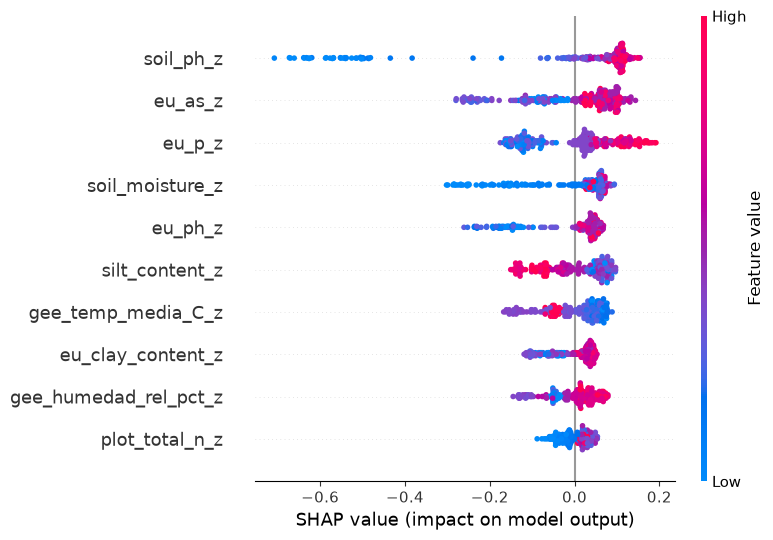

Top 10 variables por importancia SHAP (earthworm_richness_z):


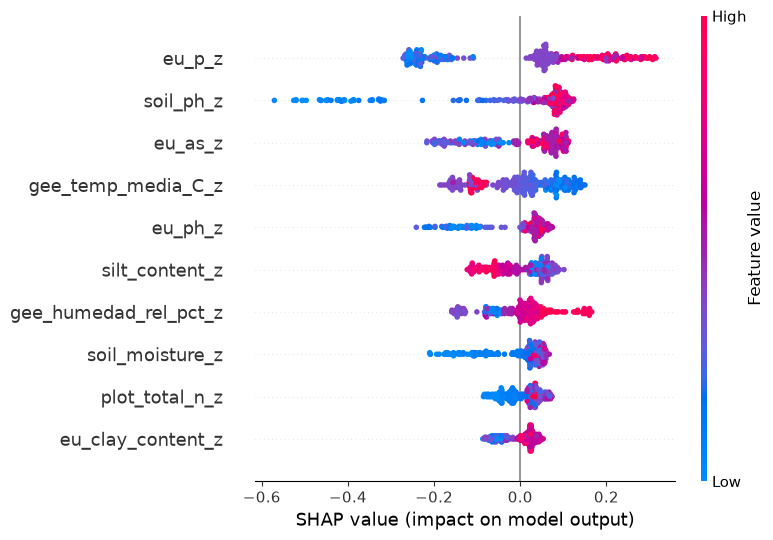

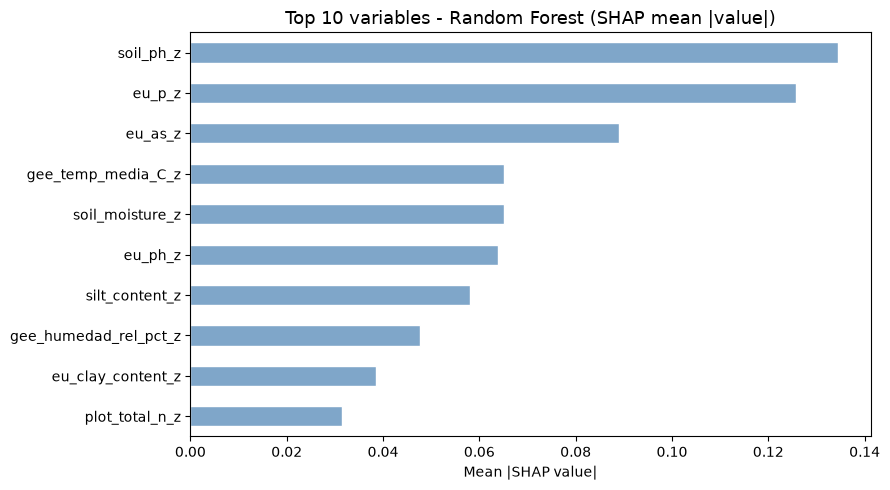

In [17]:
print('Calculando valores SHAP sobre X_train...')

# Shannon
modelo_shap_shannon = RandomForestRegressor(**RF_OPTIMAL_PARAMS)
modelo_shap_shannon.fit(X_train, y_train['earthworm_shannon_z'].values)

# Richness
modelo_shap_richness = RandomForestRegressor(**RF_OPTIMAL_PARAMS)
modelo_shap_richness.fit(X_train, y_train['earthworm_richness_z'].values)

# TreeExplainer es compatible con RandomForest
# TreeExplainer con Shannon
explainer_shannon   = shap.TreeExplainer(modelo_shap_shannon)
shap_values_shannon = explainer_shannon.shap_values(X_train)

# TreeExplainer con Richness
explainer_richness   = shap.TreeExplainer(modelo_shap_richness)
shap_values_richness = explainer_richness.shap_values(X_train)

print('Top 10 variables por importancia SHAP (earthworm_shannon_z):')
shap.summary_plot(shap_values_shannon, X_train, plot_type='dot', max_display=10)

print('Top 10 variables por importancia SHAP (earthworm_richness_z):')
shap.summary_plot(shap_values_richness, X_train, plot_type='dot', max_display=10)

# Grafico: barplot importancia SHAP media (shannon + richness)
shap_mean = np.mean([
    np.abs(shap_values_shannon),
    np.abs(shap_values_richness)
], axis=0).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables - Random Forest (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

## 6.- Entrenamiento

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria. Esto complementa la aleatoridad intrinseca de Random Forest y reduce la varianza de las predicciones finales. Todos los modelos se guardan en disco en formato `.pkl`.

In [18]:
print('Entrenamiento de produccion (ensamble de 5 modelos por target)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    for seed_id in range(NUM_MODELOS):
        params = RF_OPTIMAL_PARAMS.copy()
        params['random_state'] = 42 + seed_id

        model = RandomForestRegressor(**params)
        model.fit(X_train, y)

        joblib.dump(model, os.path.join(MODELS_DIR, f'rf_prod_{target_col}_m{seed_id}.pkl'))

    print(f'  [{idx:2d}/{len(TARGETS)}] [{target_col:<25}] completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start)/60:.1f} minutos.')
print(f'Modelos guardados: {len(TARGETS) * NUM_MODELOS} ({NUM_MODELOS} por target).')


Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [ 1/21] [nematode_shannon_z       ] completado (0.7s)
  [ 2/21] [macro_shannon_z          ] completado (0.7s)
  [ 3/21] [earthworm_shannon_z      ] completado (0.7s)
  [ 4/21] [orib_shannon_z           ] completado (0.7s)
  [ 5/21] [meso_shannon_z           ] completado (0.7s)
  [ 6/21] [coll_shannon_z           ] completado (0.7s)
  [ 7/21] [bac_shannon_z            ] completado (0.7s)
  [ 8/21] [fun_shannon_z            ] completado (0.7s)
  [ 9/21] [euk_shannon_z            ] completado (0.7s)
  [10/21] [oomy_shannon_z           ] completado (0.7s)
  [11/21] [cerc_shannon_z           ] completado (0.7s)
  [12/21] [macro_order_richness_z   ] completado (0.7s)
  [13/21] [earthworm_richness_z     ] completado (0.7s)
  [14/21] [orib_species_richness_z  ] completado (0.6s)
  [15/21] [meso_species_richness_z  ] completado (0.7s)
  [16/21] [coll_species

## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.1489   0.9111   0.7230
  macro_shannon_z                  0.2797   0.8524   0.7140
  earthworm_shannon_z              0.5059   0.7016   0.5072
  orib_shannon_z                   0.1853   1.0322   0.8771
  meso_shannon_z                  -0.1921   1.0663   0.8869
  coll_shannon_z                  -0.4168   0.7541   0.6204
  bac_shannon_z                    0.0037   0.9995   0.6709
  fun_shannon_z                   -0.0379   1.1656   0.9416
  euk_shannon_z                    0.1596   0.8891   0.6291
  oomy_shannon_z                   0.0899   0.9973   0.7373
  cerc_shannon_z                  -0.0204   0.9046   0.6237
  macro_order_richness_z           0.3069   0.7624   0.6371
  earthworm_richness_z             0.5492   0.6131   0.4

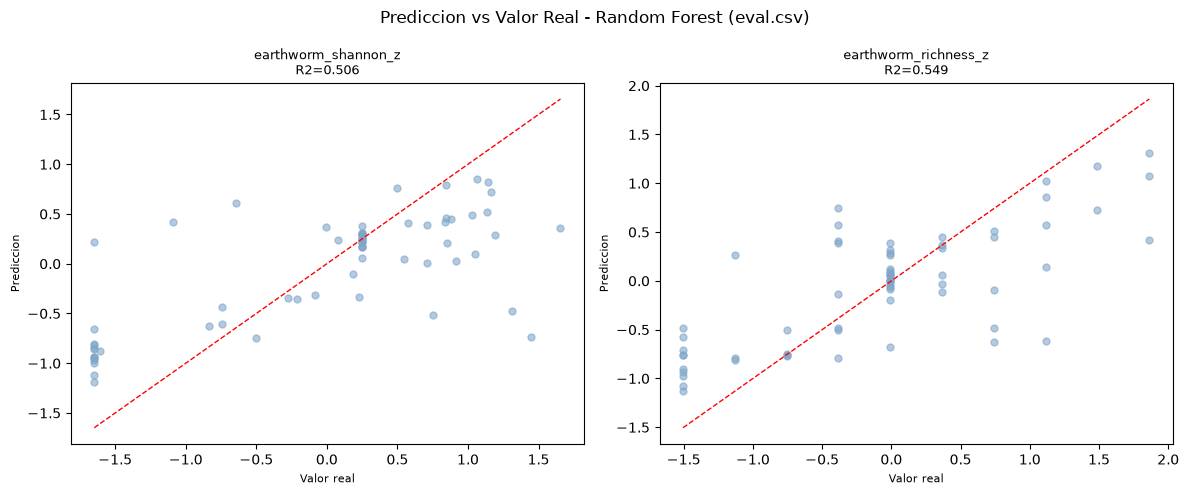

In [19]:
# Evaluacion final sobre todos los targets

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    preds_eval = []
    for seed_id in range(5):
        ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)

# Smoke test con datos reales
# Se prueban los targets representativos

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)
        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        votos = []
        for seed_id in range(5):
            ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {seed_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        consenso = np.mean(votos, axis=0)
        print('  ' + '-' * 63)
        print('  Resultados detallados:')
        print('  ' + '-' * 63)
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error: {abs(pred_val-real_val):.4f}')

    print('\nSmoke test superado. El pipeline funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    preds = [joblib.load(os.path.join(MODELS_DIR, f'rf_prod_{tgt}_m{i}.pkl')).predict(X_eval)
             for i in range(NUM_MODELOS)]
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color=PALETTE['blue'])
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - Random Forest (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()